# Bậc 1 — Perth House Prices: EDA + Baseline Models

**Data**: 33,656 giao dịch nhà thật ở Perth (Kaggle dataset).
**Pipeline**: load → clean → EDA → LinearRegression → RandomForest.

Quy tắc vàng: mọi model phải thắng được *naive baseline* (đoán giá trung bình) thì mới đáng tồn tại.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Load — "hỏi chuyện" dataset mới

In [2]:
df = pd.read_csv("perth_house_prices.csv")
print(df.shape)
df.head(3)

(33656, 19)


,ADDRESS,SUBURB,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,CBD_DIST,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,LATITUDE,LONGITUDE,NEAREST_SCH,NEAREST_SCH_DIST,NEAREST_SCH_RANK
0,1 Acorn Place,South Lake,565000,4,2,2.0,600,160,2003.0,18300,Cockburn Central Station,1800,09-2018\r,6164,-32.115900,115.842450,LAKELAND SENIOR HIGH SCHOOL,0.828339,NaN
1,1 Addis Way,Wandi,365000,3,2,2.0,351,139,2013.0,26900,Kwinana Station,4900,02-2019\r,6167,-32.193470,115.859554,ATWELL COLLEGE,5.524324,129.0
2,1 Ainsley Court,Camillo,287000,3,1,1.0,719,86,1979.0,22600,Challis Station,1900,06-2015\r,6111,-32.120578,115.993579,KELMSCOTT SENIOR HIGH SCHOOL,1.649178,113.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33656 entries, 0 to 33655
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ADDRESS           33656 non-null  str    
 1   SUBURB            33656 non-null  str    
 2   PRICE             33656 non-null  int64  
 3   BEDROOMS          33656 non-null  int64  
 4   BATHROOMS         33656 non-null  int64  
 5   GARAGE            31178 non-null  float64
 6   LAND_AREA         33656 non-null  int64  
 7   FLOOR_AREA        33656 non-null  int64  
 8   BUILD_YEAR        30501 non-null  float64
 9   CBD_DIST          33656 non-null  int64  
 10  NEAREST_STN       33656 non-null  str    
 11  NEAREST_STN_DIST  33656 non-null  int64  
 12  DATE_SOLD         33656 non-null  str    
 13  POSTCODE          33656 non-null  int64  
 14  LATITUDE          33656 non-null  float64
 15  LONGITUDE         33656 non-null  float64
 16  NEAREST_SCH       33656 non-null  str    
 17  NEAR

## 2. Clean

Ba quyết định, mỗi cái một logic khác nhau:
- `DATE_SOLD` có ký tự rác `\r` → strip rồi parse datetime
- `GARAGE` NaN → nghĩa là *không có garage* → điền 0
- `BUILD_YEAR` NaN → nhà cùng suburb thường xây cùng thời kỳ → điền **median theo suburb**
- `NEAREST_SCH_RANK` thiếu ~1/3 → bỏ cột (cho baseline)

In [4]:
df["DATE_SOLD"] = pd.to_datetime(df["DATE_SOLD"].str.strip(), format="%m-%Y", errors="coerce")
print(df.isna().sum().sort_values(ascending=False).head(5))

NEAREST_SCH_RANK    10952
BUILD_YEAR           3155
GARAGE               2478
PRICE                   0
SUBURB                  0
dtype: int64


In [5]:
df["GARAGE"] = df["GARAGE"].fillna(0)
df["BUILD_YEAR"] = df.groupby("SUBURB")["BUILD_YEAR"].transform(lambda s: s.fillna(s.median()))
df["BUILD_YEAR"] = df["BUILD_YEAR"].fillna(df["BUILD_YEAR"].median())
df = df.drop(columns=["NEAREST_SCH_RANK"])
assert df[["GARAGE", "BUILD_YEAR"]].isna().sum().sum() == 0

## 3. EDA

In [6]:
df["PRICE"].describe().apply(lambda x: f"{x:,.0f}")

count       33,656
mean       637,072
std        355,826
min         51,000
25%        410,000
50%        535,500
75%        760,000
max      2,440,000
Name: PRICE, dtype: str

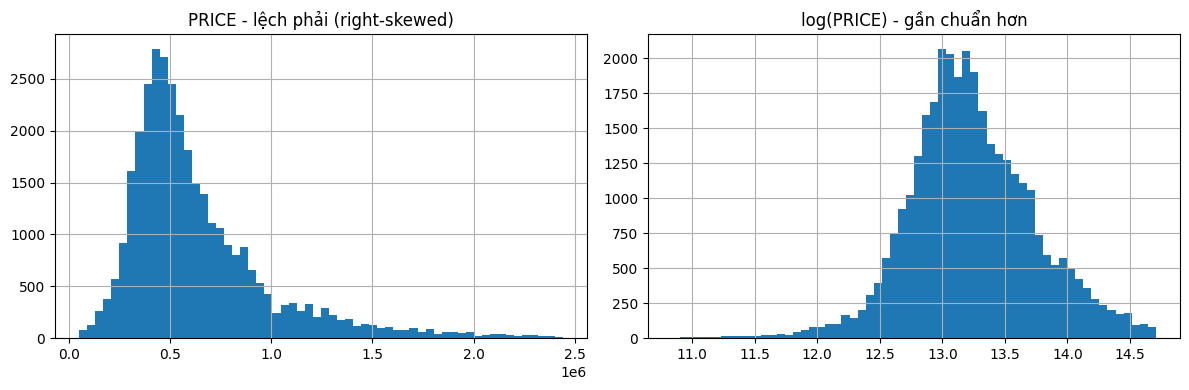

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["PRICE"].hist(bins=60, ax=ax[0])
ax[0].set_title("PRICE - lệch phải (right-skewed)")
np.log(df["PRICE"]).hist(bins=60, ax=ax[1])
ax[1].set_title("log(PRICE) - gần chuẩn hơn")
plt.tight_layout()

In [8]:
sub = df.groupby("SUBURB")["PRICE"].agg(["median", "count"])
sub = sub[sub["count"] >= 50].sort_values("median")
pd.concat([sub.tail(5), sub.head(5)]).style.format({"median": "{:,.0f}"})

,median,count
SUBURB,,
Swanbourne,"1,550,000",125
City Beach,"1,650,000",156
Nedlands,"1,667,500",104
Cottesloe,"1,690,000",69
Dalkeith,"2,039,000",73
Haynes,"195,000",115
Armadale,"210,000",63
Medina,"269,000",119
Parmelia,"271,000",114


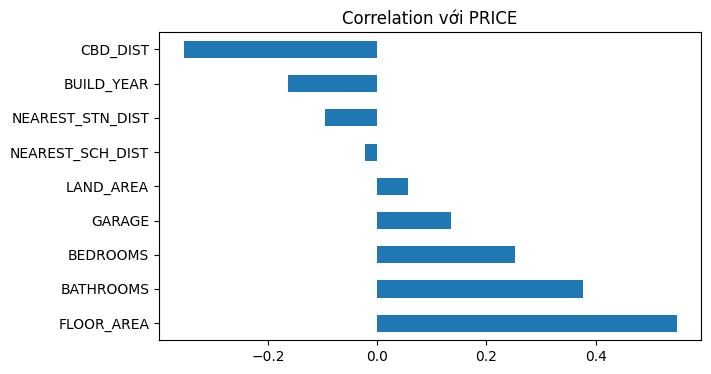

In [9]:
num_cols = ["BEDROOMS", "BATHROOMS", "GARAGE", "LAND_AREA", "FLOOR_AREA",
            "BUILD_YEAR", "CBD_DIST", "NEAREST_STN_DIST", "NEAREST_SCH_DIST"]
corr = df[num_cols + ["PRICE"]].corr()["PRICE"].drop("PRICE").sort_values(ascending=False)
corr.plot.barh(figsize=(7, 4), title="Correlation với PRICE");

## 4. Model

Chạy 3 tầng: naive → linear → random forest. MAE = sai số trung bình tính bằng AUD, dễ giải thích cho người không làm kỹ thuật.

In [10]:
X = df[num_cols]
y = df["PRICE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 26,924   Test: 6,732


In [11]:
naive_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"Naive        : MAE = ${naive_mae:,.0f}")
print(f"Linear       : MAE = ${mean_absolute_error(y_test, lr_pred):,.0f}   R2 = {r2_score(y_test, lr_pred):.3f}")
print(f"RandomForest : MAE = ${mean_absolute_error(y_test, rf_pred):,.0f}   R2 = {r2_score(y_test, rf_pred):.3f}")

Naive        : MAE = $260,718
Linear       : MAE = $170,086   R2 = 0.509
RandomForest : MAE = $124,712   R2 = 0.683


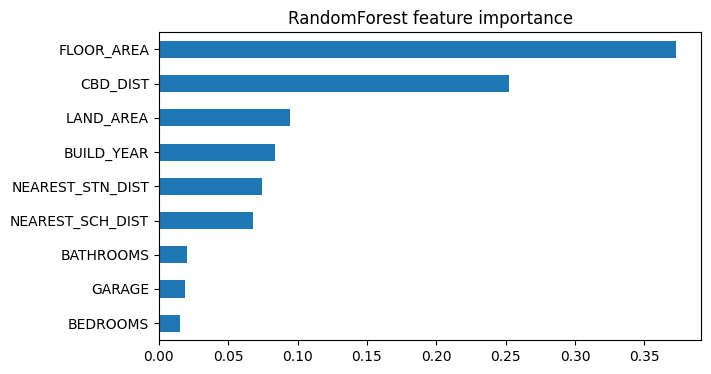

In [12]:
imp = pd.Series(rf.feature_importances_, index=num_cols).sort_values()
imp.plot.barh(figsize=(7, 4), title="RandomForest feature importance");

## 5. Câu hỏi suy ngẫm (trả lời trước buổi sau)

1. **Nghịch lý BEDROOMS**: correlation với giá = 0.253 nhưng feature importance thấp nhất bảng. Vì sao? (Gợi ý: nhìn FLOOR_AREA.)
2. Histogram cho thấy PRICE lệch phải — nếu train trên `log(PRICE)` thì MAE tính thế nào cho công bằng?
3. Đổi `random_state=42` thành số khác, MAE thay đổi — vậy báo cáo MAE nào mới là "đúng"?

**Bậc 2 (buổi sau)**: nạp CSV này vào PostgreSQL, EDA bằng SQL, kéo data về train lại — kỹ năng mới duy nhất: `psycopg2` + `pd.read_sql`.